In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 0.74  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -1.11675931 Ha
FCI能量: -1.13728383 Ha


SpinOrbitalFermions 是 NetKet（特别是 netket ≥ v3.10 之后，或通过 netket.experimental）中用于描述具有自旋的费米子系统的希尔伯特空间（Hilbert space）类。它专为处理电子结构问题（如分子、固体中的多电子系统）而设计，天然支持泡利不相容原理和固定粒子数约束。

SpinOrbitalFermions 定义了一个由自旋轨道占据数构成的离散希尔伯特空间，每个自旋轨道只能被占据（1）或空（0），且满足：

费米子统计（自动通过占据数表示处理）
可选：固定总电子数、固定自旋向上/向下电子数


In [2]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
# cluster = [(0,1),(2,3)]
#
g = nk.graph.Graph(edges=[(0,1),(2,3)])
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [3]:
import jax
import jax.numpy as jnp
from flax import nnx


class JasShort(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs):

        # Define two parameters j1, and j2.
        # Initialise them with a random normal distribution of standard deviation
        # 0.01
        # We must get a different key for each parameter, otherwise they will be
        # initialised with the same value.
        self.j1 = nnx.Param(0.01 * jax.random.normal(rngs.params(), (1,)), dtype=float)
        self.j2 = nnx.Param(0.01 * jax.random.normal(rngs.params(), (1,)), dtype=float)

    def __call__(self, x: jax.Array):

        # compute the nearest-neighbor correlations
        corr1 = x * jnp.roll(x, -1, axis=-1)
        corr2 = x * jnp.roll(x, -2, axis=-1)

        # sum the output
        return jnp.sum(self.j1 * corr1 + self.j2 * corr2, axis=-1)


# # Initialise the model wtih seed 1
# model = JasShort(rngs=nnx.Rngs(1))

# vstate = nk.vqs.MCState(sampler, model, n_samples=1008)

In [4]:
# 创建变分量子态 - 使用Slater行列式作为初始波函数
jastow_model = JasShort(rngs=nnx.Rngs(1))
vs = nk.vqs.MCState(sa, jastow_model, n_discard_per_chain=10, n_samples=512)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行优化
exp_name = "h2_molecule_jastow"

In [5]:
gs.run(300, out=exp_name)

100%|██████████| 300/300 [00:13<00:00, 22.00it/s, Energy=-0.150 ± 0.016 [σ²=0.128, R̂=1.0176]]


(JsonLog('h2_molecule_jastow', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.08687543869018555
   	Params: 0.06833219528198242,)

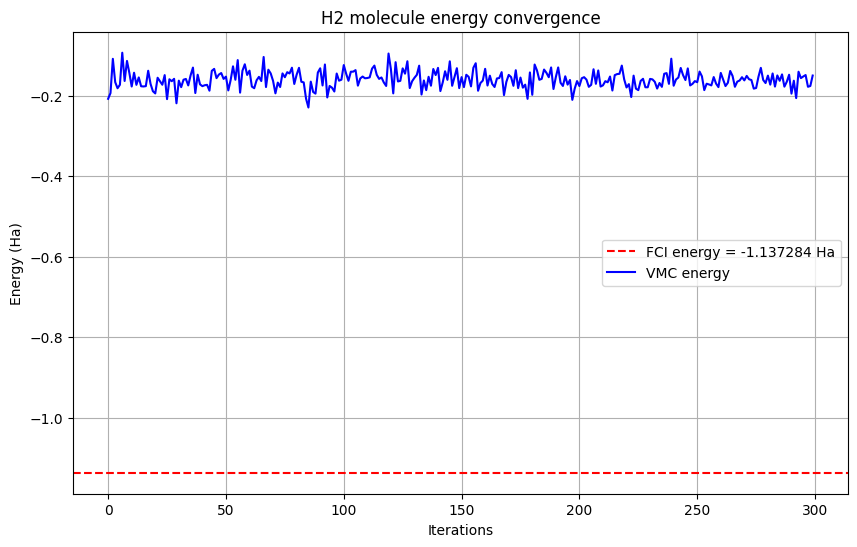


最终VMC能量: -0.14985850 Ha
与FCI能量误差: 0.98742533 Ha


In [6]:
############## 绘图 #################

# 获取精确对角化能量（FCI能量）
ed_energies = np.array([E_fci])  # H2只有一个基态能量

# 读取日志数据
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]

# 绘制能量收敛曲线
plt.figure(figsize=(10, 6))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI energy = {E_fci:.6f} Ha")
plt.plot(x, y, 'b-', label="VMC energy")
plt.xlabel("Iterations")
plt.ylabel("Energy (Ha)")
plt.title("H2 molecule energy convergence")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"\n最终VMC能量: {y[-1]:.8f} Ha")
print(f"与FCI能量误差: {abs(y[-1] - E_fci):.8f} Ha")
